<a href="https://colab.research.google.com/github/bhagvatibhatu90/UCS420/blob/main/ass_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1
### Write a unique paragraph (5-6 sentences) about your favorite topic (e.g., sports, technology, food, books, etc.).
1. Convert text to lowercase and remove punctuaƟon.
2. Tokenize the text into words and sentences.
3. Remove stopwords (using NLTK's stopwords list).
4. Display word frequency distribuƟon (excluding stopwords).

In [9]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Most common words:
[('digital', 2), ('technology', 1), ('rapidly', 1), ('transformed', 1), ('communication', 1), ('modern', 1), ('era', 1), ('people', 1), ('across', 1), ('globe', 1)]


<Axes: xlabel='Samples', ylabel='Counts'>

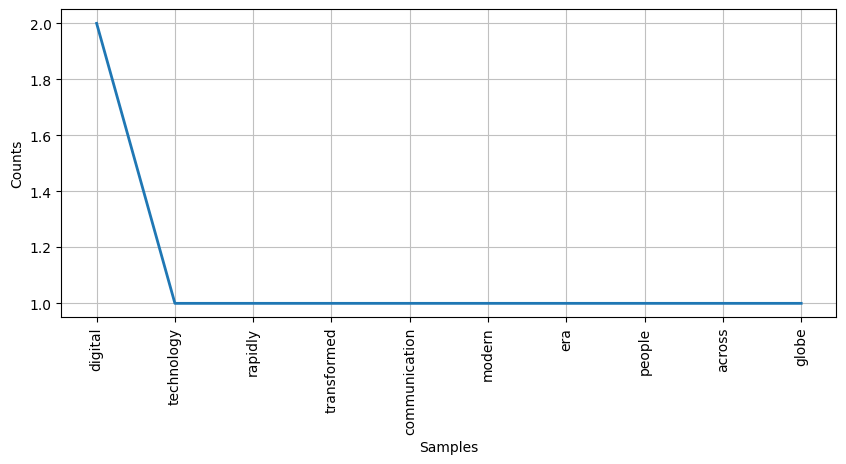

In [10]:
text = """Technology has rapidly transformed communication in the modern era.
People across the globe are now connected through social media, emails, and instant messaging platforms.
This digital shift has enabled faster information sharing, collaboration, and remote work.
Despite its benefits, concerns about privacy and digital addiction have also emerged.
Finding a balance between online engagement and mental well-being is becoming increasingly important."""

text_lower = text.lower().translate(str.maketrans('', '', string.punctuation))
word_tokens = word_tokenize(text_lower)
sent_tokens = sent_tokenize(text)
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in word_tokens if word not in stop_words]
freq = FreqDist(filtered_words)

print("Most common words:")
print(freq.most_common(10))

plt.figure(figsize=(10, 4))
freq.plot(10)


# Question 2
### Stemming and Lemmatization
1. Take the tokenized words from QuesƟon 1 (aŌer stopword removal).
2. Apply stemming using NLTK's PorterStemmer and LancasterStemmer.
3. Apply lemmaƟzaƟon using NLTK's WordNetLemmaƟzer.
4. Compare and display results of both techniques.


In [11]:
from nltk.stem import PorterStemmer, LancasterStemmer, WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

print("Word\tPorter\tLancaster\tLemma")
for word in filtered_words:
    print(f"{word}\t{porter.stem(word)}\t{lancaster.stem(word)}\t{lemmatizer.lemmatize(word)}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Word	Porter	Lancaster	Lemma
technology	technolog	technolog	technology
rapidly	rapidli	rapid	rapidly
transformed	transform	transform	transformed
communication	commun	commun	communication
modern	modern	modern	modern
era	era	er	era
people	peopl	peopl	people
across	across	across	across
globe	globe	glob	globe
connected	connect	connect	connected
social	social	soc	social
media	media	med	medium
emails	email	email	email
instant	instant	inst	instant
messaging	messag	mess	messaging
platforms	platform	platform	platform
digital	digit	digit	digital
shift	shift	shift	shift
enabled	enabl	en	enabled
faster	faster	fast	faster
information	inform	inform	information
sharing	share	shar	sharing
collaboration	collabor	collab	collaboration
remote	remot	remot	remote
work	work	work	work
despite	despit	despit	despite
benefits	benefit	benefit	benefit
concerns	concern	concern	concern
privacy	privaci	priv	privacy
digital	digit	digit	digital
addiction	addict	addict	addiction
also	also	also	also
emerged	emerg	emerg	em

# Question 3. Regular Expressions and Text Spliƫng
1. Take their original text from Question 1.
2. Use regular expressions to:

    - a. Extract all words with more than 5 letters.

    - b. Extract all numbers (if any exist in their text).

    - c. Extract all capitalized words.
3. Use text spliƫng techniques to:
   
    - a. Split the text into words containing only alphabets (removing digits and specialcharacters).
    - b. Extract words starting with a vowel.

In [13]:
import re

long_words = re.findall(r'\b\w{6,}\b', text)
numbers = re.findall(r'\b\d+\b', text)
capitalized = re.findall(r'\b[A-Z][a-z]*\b', text)
alpha_only = re.findall(r'\b[a-zA-Z]+\b', text)
vowel_words = [w for w in alpha_only if re.match(r'^[aeiouAEIOU]', w)]

print("Words >5 letters:", long_words)
print("Capitalized:", capitalized)
print("Words starting with vowel:", vowel_words)


Words >5 letters: ['Technology', 'rapidly', 'transformed', 'communication', 'modern', 'People', 'across', 'connected', 'through', 'social', 'emails', 'instant', 'messaging', 'platforms', 'digital', 'enabled', 'faster', 'information', 'sharing', 'collaboration', 'remote', 'Despite', 'benefits', 'concerns', 'privacy', 'digital', 'addiction', 'emerged', 'Finding', 'balance', 'between', 'online', 'engagement', 'mental', 'becoming', 'increasingly', 'important']
Capitalized: ['Technology', 'People', 'This', 'Despite', 'Finding']
Words starting with vowel: ['in', 'era', 'across', 'are', 'emails', 'and', 'instant', 'enabled', 'information', 'and', 'its', 'about', 'and', 'addiction', 'also', 'emerged', 'a', 'online', 'engagement', 'and', 'is', 'increasingly', 'important']


# Q4. Custom Tokenization & Regex-based Text Cleaning

## Steps:

1. **Input**: Use the original text from **Question 1**.

2. **Custom Tokenization Function Requirements**:
   
   - **(a)** Remove punctuation and special symbols, **but keep contractions** (e.g., `"isn't"` should remain `"isn't"` and not split into `"is"` and `"n't"`).
   
   - **(b)** Handle **hyphenated words** as **single tokens** (e.g., `"state-of-the-art"` should remain as one token).
   
   - **(c)** **Tokenize numbers separately**, but **keep decimal numbers intact** (e.g., `"3.14"` should remain `"3.14"`).

3. **Regex Substitutions** (using `re.sub`):

   - **(a)** Replace **email addresses** with the placeholder `<EMAIL>`.
   
   - **(b)** Replace **URLs** with the placeholder `<URL>`.
   
   - **(c)** Replace **phone numbers** (formats like `123-456-7890` or `+91 9876543210`) with the plceho-z0-9.-]+\.[A-Z|a-z]{2,}\b
placeholder.

In [15]:
def custom_tokenizer(text):
    pattern = r"\b(?:[A-Za-z]+(?:'[a-z]+)?|[0-9]+(?:\.[0-9]+)?|[A-Za-z]+(?:-[A-Za-z]+)+)\b"
    return re.findall(pattern, text)

tokens = custom_tokenizer(text)
print("Custom Tokens:", tokens)

def clean_text(sample_text):
    sample_text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w{2,4}\b', '<EMAIL>', sample_text)
    sample_text = re.sub(r'https?://\S+|www\.\S+', '<URL>', sample_text)
    sample_text = re.sub(r'(\+91[-\s]?|0)?[6-9]\d{9}|\d{3}-\d{3}-\d{4}', '<PHONE>', sample_text)
    return sample_text

example = "Reach out at ai.tech@example.com or visit https://aifuture.org. Call me at +91 9876543210."
print("Cleaned Example:", clean_text(example))


Custom Tokens: ['Technology', 'has', 'rapidly', 'transformed', 'communication', 'in', 'the', 'modern', 'era', 'People', 'across', 'the', 'globe', 'are', 'now', 'connected', 'through', 'social', 'media', 'emails', 'and', 'instant', 'messaging', 'platforms', 'This', 'digital', 'shift', 'has', 'enabled', 'faster', 'information', 'sharing', 'collaboration', 'and', 'remote', 'work', 'Despite', 'its', 'benefits', 'concerns', 'about', 'privacy', 'and', 'digital', 'addiction', 'have', 'also', 'emerged', 'Finding', 'a', 'balance', 'between', 'online', 'engagement', 'and', 'mental', 'well', 'being', 'is', 'becoming', 'increasingly', 'important']
Cleaned Example: Reach out at <EMAIL> or visit <URL> Call me at <PHONE>.
